# C1 Practical 24: from tide gauges to global mean sea level

*Lectures 23 and 24. Michaelmas 2026.*


> Open this notebook in Google Colab with the button on the course page, then choose *File > Save a copy in Drive*
> so that your changes are kept. Questions marked **[paper]** are answered on paper. Cells marked *run* need
> only be run; some have settings you can change, which appear as sliders and menus in Colab. A changed setting
> takes effect only when the cell is run again.


**Constants.** 360 Gt of ice is one millimetre of global mean sea level; Earth radius 6371 km.

> **Solutions version.** Cells beginning *Answer* are the worked solutions and demonstrator notes.

In [ ]:
#@title Run this cell first. It fetches the data files and a small helper module.
import os, sys, pathlib, urllib.request
BASE = "https://raw.githubusercontent.com/da380/c1-practicals/main/"
here = pathlib.Path("../data") if pathlib.Path("../data/c1prac.py").exists() else pathlib.Path("data")
here.mkdir(exist_ok=True)
if not pathlib.Path("../data/c1prac.py").exists():          # in Colab: start from clean copies of the helper module and the data
    for old in here.glob("*"):
        if old.suffix in (".py", ".npz", ".csv", ".json"):
            old.unlink()
    urllib.request.urlretrieve(BASE + "data/c1prac.py", here / "c1prac.py")
    for m in [k for k in sys.modules if k == "c1prac"]:
        del sys.modules[m]
sys.path.insert(0, str(here))
try:
    import pyslfp
except ImportError:                       # in Colab: about a minute
    import subprocess; subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyslfp"], check=True); import pyslfp
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
_ = list(cfeature.COASTLINE.geometries())      # fetch the coastline data once, here, rather than in a results cell
from pyslfp import subplots, plot_points
from c1prac import get, load_json, global_map, regional_map, weighted_least_squares
print("Ready.")

## 1. Two warm-ups from Lecture 23  [paper]

**(a) The budget as a difference of large numbers.** Greenland receives about 700 Gt yr$^{-1}$ of snow, loses about
250 Gt yr$^{-1}$ as melt-water runoff, and discharges about 500 Gt yr$^{-1}$ of ice across its grounding lines. Suppose
each of these is known to ten per cent. What is the rate of mass change and its uncertainty, in Gt yr$^{-1}$ and in mm
yr$^{-1}$ of sea level? Comment on what this means for the input-output method. (Independent errors combine in
quadrature: the uncertainty of a sum or difference of quantities is the square root of the sum of their squared
uncertainties, $\sqrt{\sigma_1^2 + \sigma_2^2 + \cdots}$.)

**(b) Resolution.** A spherical harmonic of degree $l$ has a half-wavelength of about $20\,000/l$ km. What degree is
needed to separate Greenland from Ellesmere Island, 500 km away across Nares Strait? What does truncation at degree 60
mean for an outlet glacier ten kilometres wide? Why are the degree-one coefficients absent from the satellite gravity
field, and what does their absence do to the Antarctic mass balance?

**Answer.** **(a)** $dM/dt = 700 - 250 - 500 = -50$ Gt yr$^{-1}$, with uncertainty $\sqrt{70^2 + 25^2 + 50^2} \approx 90$ Gt yr$^{-1}$:
that is $-0.14 \pm 0.25$ mm yr$^{-1}$. The imbalance is a small difference of large terms, and its uncertainty exceeds
the signal even though each term is known to ten per cent. The input-output method is therefore poor at the absolute
number, but because it separates the terms it is the best method for saying *why* the mass is changing and the only one
that reaches back before the satellite era.

**(b)** $l \approx 20\,000/500 = 40$. At degree 60 the half-wavelength is about 330 km, so a ten-kilometre glacier is
invisible: only the sum of the loss over a few hundred kilometres of coast is recovered (a degree of about 2000 would
be needed). The degree-one terms describe a shift of the centre of mass relative to the solid Earth; the satellites
orbit the centre of mass, so this shift is invisible to them and must be supplied from a model of how the melt water
is distributed. Left out, it biases the Antarctic balance by tens of gigatonnes per year, a third of the signal,
because Antarctic melt moves mass from the southern to the northern hemisphere.

**Cell A** takes the load of one year of Greenland ice loss (250 Gt, distributed like the present ice sheet) and smooths
it over the sphere with Gaussian kernels of increasing width, from about 200 km to 1000 km: the resolutions of gravity
fields that stop at degrees 96 down to 20. It then integrates each smoothed field over Greenland.

In [ ]:
#@title Cell A: the same load seen at decreasing resolution
tr = np.load(get("greenland_truncation.npz")); lon, lat, mask = tr["lon"], tr["lat"], tr["mask"]
fig, axes = subplots(2, 2, ccrs.PlateCarree(), figsize=(13, 8.5))
for ax, L, hw in zip(axes.flat, tr["degrees"][::-1], tr["halfwidth_km"][::-1]):
    regional_map(tr[f"ewt_L{L}"] * 1000, lon, lat, lon_range=(-80, 0), lat_range=(55, 85), ax=ax, vmin=-150, vmax=150, cmap="RdBu",
                 title=f"smoothed over {hw:.0f} km (about degree {L})", label="mm of water")
    ax.contour(lon, lat, mask, levels=[0.5], colors="g", linewidths=1, transform=ccrs.PlateCarree())
plt.show()
print()
for L, hw, gt in zip(tr["degrees"][::-1], tr["halfwidth_km"][::-1], tr["gt_over_greenland"][::-1]):
    print(f"smoothed over {hw:5.0f} km (about degree {int(L):3d}):  integral over Greenland (green outline) = {gt:6.1f} Gt of the 250 Gt removed")

**(c)** Describe what happens to the load as the smoothing scale grows, and explain why the integral over Greenland
falls below 250 Gt. This is *leakage*. What assumption is needed to correct for it?

**Answer.** **(c)** As the smoothing scale grows the sharp edge of the ice sheet is smeared over a few hundred kilometres: mass
appears to be lost from the surrounding ocean and from Ellesmere Island, and the amplitude over the ice falls. The
smoothing conserves mass, so whatever has been smeared beyond the outline is missing from the integral inside it:
248 Gt is recovered at 208 km, 241 at 333 km, 219 at 500 km and only
138 at 1000 km. To correct it one must assume where the mass actually is, for example that all of it
lies on the ice sheet and that the ocean part is the smeared image of it, which is the assumption a leakage correction
or a mascon prior encodes. (Cutting the expansion off sharply at a degree, instead of smoothing, would add ringing, a
negative halo around the ice sheet, and can push the integral either way; the satellite solutions smooth for this reason.)

## 2. The weighted mean and its bias  [paper]

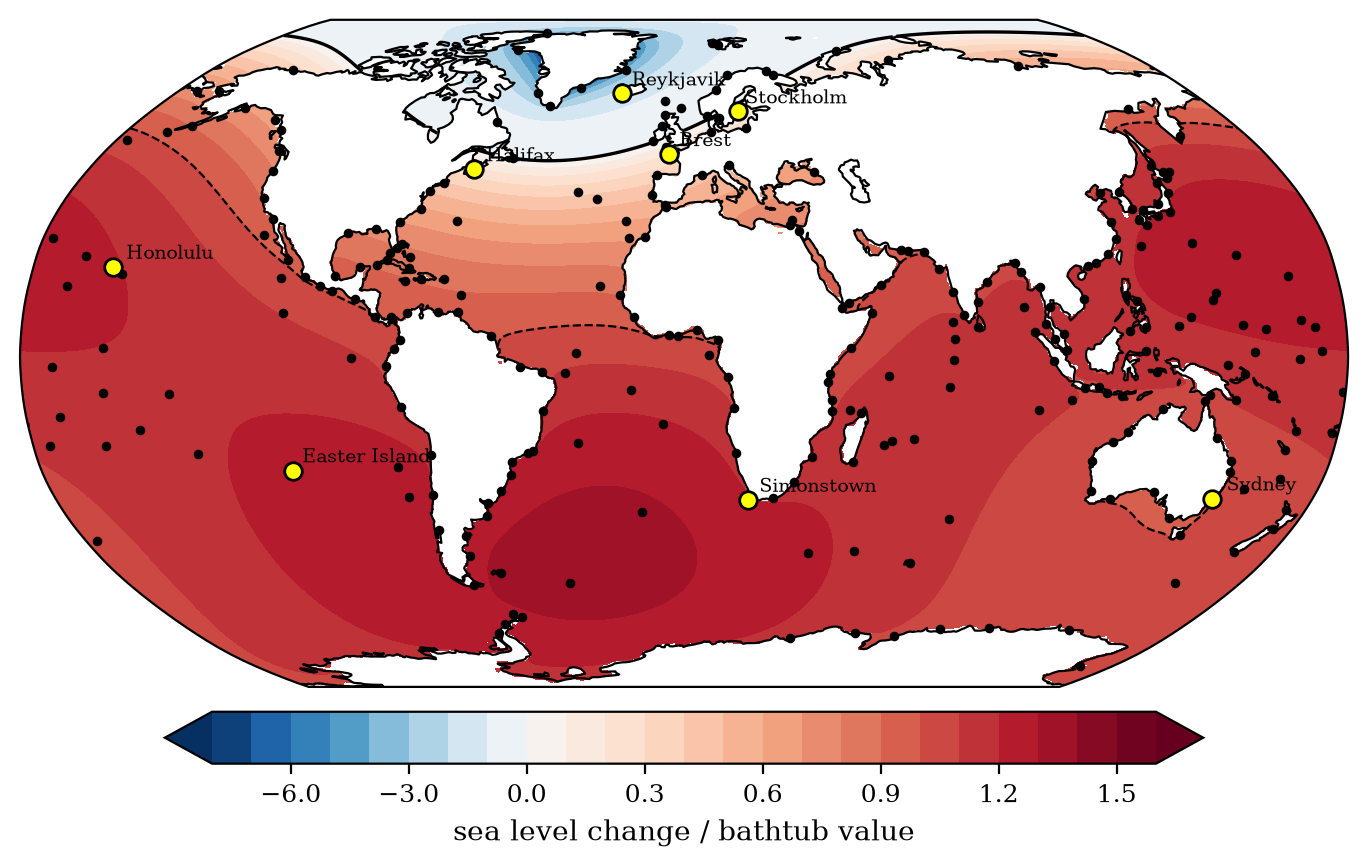<p style="font-size:90%;color:#444"><em>The Greenland fingerprint, normalised by its barystatic value, with the GLOSS tide gauge network.</em></p>

Four tide gauges record the change in relative sea level over one year. The readings have been corrected for glacial
isostatic adjustment, ocean dynamics and local land motion, with the uncertainties of the corrections included in the
standard deviations. Within a simple model the change at gauge $i$ is a weighted sum of the barystatic contributions
$\Delta B_j$ of the three ice sheets,
$$ \Delta SL_i = a_{iG}\,\Delta B_G + a_{iW}\,\Delta B_W + a_{iE}\,\Delta B_E + \epsilon_i , $$
where the coefficients are the values of the three fingerprints at the gauge (each normalised to unit ocean mean)
and $\epsilon_i$ is a random error of standard deviation $\sigma_i$.

| Gauge | lat | lon | $a_{iG}$ (Greenland) | $a_{iW}$ (West Antarctica) | $a_{iE}$ (East Antarctica) | reading / mm | $\sigma$ / mm |
|---|---|---|---|---|---|---|---|
| Stockholm | 59.3 | 18.1 | 0.076 | 1.013 | 1.072 | 0.449 | 0.02 |
| Halifax | 44.7 | -63.6 | 0.223 | 1.230 | 1.066 | 0.634 | 0.01 |
| Honolulu | 21.3 | -157.9 | 1.206 | 1.296 | 1.213 | 1.335 | 0.01 |
| Simonstown | -34.2 | 18.4 | 1.209 | 1.119 | 0.913 | 1.315 | 0.03 |

**(a)** Estimate the global mean sea level rise by forming the weighted mean of the four readings,
$$ \overline{\Delta SL} = \frac{\sum_i w_i\,\Delta SL_i}{\sum_i w_i}, \qquad w_i = \frac{1}{\sigma_i^2}, $$
which gives most weight to the most precise readings.

**(b)** Show that the weighted mean is, apart from the random errors, a combination
$b_G\,\Delta B_G + b_W\,\Delta B_W + b_E\,\Delta B_E$ of the ice-sheet contributions, derive the expression for $b_j$, and
evaluate the three coefficients.

**(c)** The true global mean rise is $\Delta B_G + \Delta B_W + \Delta B_E$. Is your estimate in (a) biased, in which
direction, and why? Which network of gauges would count Greenland correctly?

**Least squares.** The three contributions can instead be estimated together by *weighted least squares*. The method
is this: choose the values of $\Delta B_G$, $\Delta B_W$, $\Delta B_E$ that make the weighted sum of squared residuals
$\sum_i w_i\,(\Delta SL_i - \sum_j a_{ij}\Delta B_j)^2$ as small as possible. Setting its derivative with respect to each
unknown to zero gives three linear equations, the *normal equations*,
$$ \sum_j \Big(\sum_i w_i\, a_{ik}\, a_{ij}\Big)\,\Delta B_j = \sum_i w_i\, a_{ik}\,\Delta SL_i , \qquad k = G, W, E, $$
or in matrix form $(A^T W A)\,\Delta B = A^T W\, d$, so that
$$ \Delta B = (A^T W A)^{-1} A^T W\, d , $$
where $A$ is the 4 by 3 table of coefficients, $W$ the diagonal matrix of the weights and $d$ the column of readings.
The derivation is given in the solutions. The cell below forms the matrix and the right-hand side from the table and
solves for the three contributions.

In [ ]:
#@title Run: weighted least squares for the four gauges
G = load_json("p24_gauges.json")["gauges"]
A = np.array([r["a"] for r in G]); d = np.array([r["reading"] for r in G]); w = 1 / np.array([r["sigma"] for r in G]) ** 2
N = A.T @ (w[:, None] * A); rhs = A.T @ (w * d)
print("normal matrix A^T W A (rows and columns: Greenland, West Antarctica, East Antarctica):"); print(np.round(N, 1))
print("right-hand side A^T W d:", np.round(rhs, 2))
m = np.linalg.solve(N, rhs)
print()
print(f"least-squares solution: Greenland {m[0]:.3f}, West Antarctica {m[1]:.3f}, East Antarctica {m[2]:.3f} mm;  total {m.sum():.3f} mm")
print(f"weighted mean of the readings, for comparison: {np.sum(w * d) / np.sum(w):.3f} mm")

**(d)** Why is the least-squares estimate of the total unbiased when the weighted mean is not, and what does it assume?

**Answer.** **(a)** Weights: Stockholm 2500, Halifax 10000, Honolulu 10000, Simonstown 1111 mm$^{-2}$, sum 23611. Weighted mean
$= 0.943$ mm.

**(b)** Substituting the model into the mean,
$\overline{\Delta SL} = \sum_i w_i \sum_j a_{ij}\Delta B_j / \sum_i w_i + \text{errors} = \sum_j b_j\,\Delta B_j + \text{errors}$
with $b_j = \sum_i w_i a_{ij} / \sum_i w_i$. The values are $b_G = 0.670$, $b_W = 1.230$, $b_E = 1.122$.

**(c)** Yes. If the coefficients were all one the mean would estimate the true total; they are not, so the estimate
counts Greenland at only 67 per cent and the Antarctic ice sheets at 123 and 112 per cent. (The readings
were in fact generated from $\Delta B_G = 0.7$, $\Delta B_W = 0.3$, $\Delta B_E = 0.1$ mm, a true
total of 1.10 mm; the expected value of the weighted mean is 0.95 mm, a bias of -14 per cent, and
the noise is small beside it.) The bias arises because the sea level change is not a constant plus noise but has a
systematic spatial pattern set by where the mass came from, and this network, with its two precise northern gauges near
Greenland's zero contour, sits where the Greenland signal is below its mean. A network that counts Greenland correctly
would need its weight distributed so that $\sum w_i a_{iG} / \sum w_i = 1$, for example more weight in the far field of
Greenland (the southern oceans) and less in the North Atlantic; no real network does this for all three sources at
once.

**(d)** *Derivation.* Write $S = \sum_i w_i\,r_i^2$ with residuals $r_i = \Delta SL_i - \sum_j a_{ij}\Delta B_j$. Then
$\partial S/\partial \Delta B_k = -2\sum_i w_i\, a_{ik}\, r_i$, and setting this to zero for each $k$ gives
$\sum_i w_i a_{ik}\Delta SL_i = \sum_j (\sum_i w_i a_{ik} a_{ij})\Delta B_j$, which is $A^T W d = A^T W A\,\Delta B$ written out.
*Numbers.* With the weights above, $A^T W A$ has rows (16680, 20068, 18436), (20068, 35882, 32682) and
(18436, 32682, 29876) mm$^{-2}$, and $A^T W d = (19365.7, 27871.9, 25489.3)$ mm$^{-1}$. Solving gives
$\Delta B = (0.69, 0.44, -0.06)$ mm, a total of 1.08 mm against the true 1.10 mm. The estimate is
unbiased because the model is linear in the unknowns and, if the fingerprints are correct, substituting the true
model back reproduces the true amplitudes whatever they are; the weighted mean, by contrast, assumes a pattern (a
constant) that the physics does not produce. The least-squares estimate assumes that the patterns are known exactly
and that the three sources are the only ones, and with four gauges the Antarctic pair is poorly separated (standard
errors 0.09 and 0.10 mm, strongly anti-correlated).

**Cell B.** The same experiment with all 290 gauges of the GLOSS network. Set the true contributions and the noise;
the cell generates readings, forms the weighted mean and the least-squares fit, and compares both with the truth.
Try changing the mix of sources at fixed total, and try restricting the network to the northern hemisphere.

In [ ]:
#@title Cell B: weighted mean versus least squares over the GLOSS network
greenland_mm = 0.7  #@param {type:"slider", min:0, max:2, step:0.1}
west_antarctic_mm = 0.3  #@param {type:"slider", min:0, max:2, step:0.1}
east_antarctic_mm = 0.1  #@param {type:"slider", min:0, max:2, step:0.1}
noise_mm = 0.3  #@param {type:"slider", min:0.05, max:2, step:0.05}
network = "all gauges"  #@param ["all gauges", "northern hemisphere only", "southern hemisphere only"]
import csv
rows = list(csv.DictReader(open(get("gloss_fingerprints.csv"))))
lat = np.array([float(r["lat"]) for r in rows]); lon = np.array([float(r["lon"]) for r in rows])
A = np.array([[float(r["a_greenland"]), float(r["a_west_antarctic"]), float(r["a_east_antarctic"])] for r in rows])
keep = {"all gauges": lat > -90, "northern hemisphere only": lat > 0, "southern hemisphere only": lat < 0}[network]
A, lat, lon = A[keep], lat[keep], lon[keep]
truth = np.array([greenland_mm, west_antarctic_mm, east_antarctic_mm])
rng = np.random.default_rng(1)
sigma = np.full(len(A), noise_mm)
d = A @ truth + rng.normal(0, noise_mm, len(A))
wmean = d.mean()
b = A.mean(axis=0)
m, cov, res = weighted_least_squares(A, d, sigma)
err = np.sqrt(np.diag(cov)); corr = cov / np.outer(err, err)
fig, ax = subplots(1, 1, ccrs.Robinson(), figsize=(11.7, 5.85))
plot_points(list(zip(lat, lon)), data=d, ax=ax, s=18, cmap="RdBu_r", vmin=truth.sum() - 1.5, vmax=truth.sum() + 1.5, gridlines=False,
            colorbar=True, colorbar_kwargs={"label": "reading / mm", "shrink": 0.6})
ax.set_title("synthetic readings at the gauges"); plt.show()
print()
print(f"{len(A)} gauges.  True contributions: Greenland {truth[0]:.2f}, West Antarctica {truth[1]:.2f}, East Antarctica {truth[2]:.2f} mm;  true total {truth.sum():.2f} mm.")
print()
print(f"Mean of the readings: {wmean:.2f} mm.")
print(f"   Averaged over these gauges, the fingerprints count Greenland at {b[0]:.2f}, West Antarctica at {b[1]:.2f} and East Antarctica at {b[2]:.2f}")
print(f"   of their true contributions, so without any noise the mean would be {b @ truth:.2f} mm: a bias of {b @ truth - truth.sum():+.2f} mm.")
print()
print(f"Least squares: Greenland {m[0]:.2f} +/- {err[0]:.2f}, West Antarctica {m[1]:.2f} +/- {err[1]:.2f}, East Antarctica {m[2]:.2f} +/- {err[2]:.2f} mm;")
print(f"   total {m.sum():.2f} +/- {np.sqrt(np.ones(3) @ cov @ np.ones(3)):.2f} mm;  correlation between the two Antarctic estimates {corr[1, 2]:+.2f}.")

## 3. Meltwater pulse 1A  [run]

Between about 14.7 and 14.2 ka global mean sea level rose by some 15 to 20 metres in a few centuries, the fastest rise in
the record. The sources have been argued over since Clark et al. (2002) first applied fingerprints to the two records then
available, Barbados and the Sunda Shelf; Tahiti's record of the pulse came only with the drilling reported by Deschamps
et al. (2012). Lin et al. (2021, *Nature Communications*) used six sites, adding Tahiti, two on the Great Barrier Reef
and the isolation basins of north-west Scotland, and inverted for three sources.

Here the geometry of the melt comes from the ICE-7G reconstruction: the change in ice thickness between 14.5 and 14.0 ka,
split into North America (including Greenland), Eurasia (Scandinavia and the Barents Sea, excluding the small British
ice sheet) and Antarctica. Each pattern has been normalised to one metre of barystatic rise and its elastic
fingerprint computed on the Earth of 14.5 ka, with its own shorelines, so the values at a site are the metres of local
rise per metre of global rise from that source. The local rises are the medians and standard deviations of the Lin et
al. reconstructions for a 500-year pulse.

| Site | lat | lon | local rise / m | $\sigma$ / m | $a$ (N. America) | $a$ (Eurasia) | $a$ (Antarctica) |
|---|---|---|---|---|---|---|---|
| Tahiti | -17.5 | -149.5 | 21.4 | 3.6 | 1.24 | 1.04 | 1.16 |
| Barbados | 13.1 | -59.5 | 15.6 | 1.7 | 0.82 | 1.01 | 1.21 |
| Sunda Shelf | 4.0 | 107.0 | 15.5 | 9.7 | 1.05 | 0.97 | 1.08 |
| Hydrographer's Passage | -19.7 | 150.3 | 19.9 | 5.7 | 1.06 | 1.00 | 1.19 |
| Noggin Pass | -17.1 | 146.6 | 19.2 | 6.6 | 1.04 | 1.01 | 1.18 |
| NW Scotland | 57.4 | -5.8 | 8.5 | 3.6 | 0.74 | -0.64 | 1.14 |

**Cell C** maps the three fingerprints on the 14.5 ka Earth. The shorelines drawn are those of 14.5 ka, where the sea
level of that epoch crosses zero; much of the Sunda Shelf and the North Sea was land.

In [ ]:
#@title Cell C: the three fingerprints at 14.5 ka
mw = np.load(get("mwp1a_fingerprints.npz")); lon, lat, ocean = mw["lon"], mw["lat"], mw["ocean"]
sites = {r["name"]: (r["lat"], r["lon"]) for r in load_json("mwp1a_sites.json")["sites"]}
fig, axes = subplots(1, 3, ccrs.Robinson(), figsize=(18.2, 5.07))
for k, (ax, key) in enumerate(zip(axes.flat, ["north_america", "eurasia", "antarctica"])):
    global_map(mw[key + "_sl"], lon, lat, ax=ax, vmin=-8, vmax=1.6, center=0, ocean=ocean, contours=(0.0, 1.0), sites=sites if k == 0 else None,
               coast_field=mw["sea_level_epoch"], title=key.replace("_", " "), label="/ bathtub value")
plt.show()

**Cell D. Fit by hand.** Starting from zero, set the metres of global mean rise from each source and compare the
predicted local rise at the six sites with the observations. Find a combination that fits all six, then see how much
you can change it while still fitting. Note which sites discriminate between sources and which only fix the total.

In [ ]:
#@title Cell D: turn the knobs
north_america_m = 0.0  #@param {type:"slider", min:0, max:25, step:0.5}
eurasia_m = 0.0  #@param {type:"slider", min:0, max:12, step:0.5}
antarctica_m = 0.0  #@param {type:"slider", min:0, max:15, step:0.5}
S = load_json("mwp1a_sites.json")["sites"]
names = [r["name"] for r in S]; A = np.array([r["a_ours"] for r in S]); d = np.array([r["median_m"] for r in S]); s = np.array([r["sigma_m"] for r in S])
m = np.array([north_america_m, eurasia_m, antarctica_m]); pred = A @ m
chi2 = np.sum(((d - pred) / s) ** 2)
fig, ax = plt.subplots(figsize=(10.4, 5.2))
x = np.arange(len(names)); ax.errorbar(x, d, yerr=s, fmt="ko", capsize=4, label="observed (Lin et al. 2021)")
ax.bar(x, pred, color="C0", alpha=0.6, label="predicted"); ax.axhline(m.sum(), color="C3", ls="--", label=f"global mean {m.sum():.1f} m")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=25, ha="right"); ax.set_ylabel("sea level rise during MWP1A / m"); ax.legend(frameon=False); plt.show()
print(f"global mean rise {m.sum():.1f} m;  chi-squared = {chi2:.1f} for 6 data (a good fit has chi-squared of about 3 to 6)")
for n, p, dd, ss in zip(names, pred, d, s):
    print(f"  {n:<24s} predicted {p:5.1f}  observed {dd:5.1f} +/- {ss:4.1f}")

**Cell E. Inversion.** The same problem solved by weighted least squares, with the choice of which sites to use.
Compare the six-site solution with the two sites available to Clark et al. (2002), and look at what happens to the
Antarctic estimate when Scotland is removed. With fewer sites than sources there is no unique least-squares solution,
and the cell then shows only the misfit surface. That surface gives the misfit as a function of the North American
and Antarctic contributions, with the Eurasian contribution adjusted to its best value at each point.

In [ ]:
#@title Cell E: least-squares inversion for the three sources
use_Tahiti = True  #@param {type:"boolean"}
use_Barbados = True  #@param {type:"boolean"}
use_Sunda_Shelf = True  #@param {type:"boolean"}
use_Hydrographers_Passage = True  #@param {type:"boolean"}
use_Noggin_Pass = True  #@param {type:"boolean"}
use_NW_Scotland = True  #@param {type:"boolean"}
S = load_json("mwp1a_sites.json")["sites"]
flags = [use_Tahiti, use_Barbados, use_Sunda_Shelf, use_Hydrographers_Passage, use_Noggin_Pass, use_NW_Scotland]
keep = [k for k, f in enumerate(flags) if f]
names = [S[k]["name"] for k in keep]; A = np.array([S[k]["a_ours"] for k in keep]); d = np.array([S[k]["median_m"] for k in keep]); s = np.array([S[k]["sigma_m"] for k in keep])
print("sites used:", ", ".join(names))
solved = len(keep) >= 3
if solved:
    m, cov, res = weighted_least_squares(A, d, s); err = np.sqrt(np.diag(cov)); corr = cov / np.outer(err, err)
    for lab, mi, ei in zip(["North America", "Eurasia", "Antarctica"], m, err):
        print(f"  {lab:<14s} {mi:6.1f} +/- {ei:4.1f} m")
    print(f"  total          {m.sum():6.1f} +/- {np.sqrt(np.ones(3) @ cov @ np.ones(3)):4.1f} m;   chi-squared {np.sum((res / s) ** 2):.1f} for {len(d)} data")
    print("correlation matrix (NA, EU, AA):"); print(np.round(corr, 2))
else:
    print(f"  only {len(keep)} sites for 3 unknowns: no unique least-squares solution; the misfit surface shows the family of fits")
print("Lin et al. (2021), six sites with a GIA model and non-negativity: North America 12.0 (5.6-15.4), Scandinavia 4.6 (3.2-6.4), Antarctica 1.3 (0-5.9), total 17.9 (15.7-20.2) m")
# misfit surface over (North America, Antarctica) with Eurasia optimised
na = np.linspace(0, 25, 126); aa = np.linspace(0, 15, 76); chi = np.zeros((aa.size, na.size))
w = 1 / s ** 2
for i, y in enumerate(aa):
    for j, x in enumerate(na):
        r = d - A[:, 0] * x - A[:, 2] * y
        e = np.sum(w * A[:, 1] * r) / np.sum(w * A[:, 1] ** 2)
        e = max(e, 0.0)
        chi[i, j] = np.sum(w * (r - A[:, 1] * e) ** 2)
fig, ax = plt.subplots(figsize=(8.45, 5.85))
cs = ax.contourf(na, aa, chi - chi.min(), levels=[0, 1, 2.3, 4, 6.2, 9, 12, 20, 50, 200], cmap="viridis_r", extend="max")
fig.colorbar(cs, label="increase in chi-squared above the minimum")
if solved:
    ax.plot(m[0], m[2], "r*", ms=12, label="least squares")
ax.plot(12.0, 1.3, "wo", label="Lin et al. 2021")
ax.set_xlabel("North America / m"); ax.set_ylabel("Antarctica / m"); ax.legend(frameon=False); ax.set_title("misfit with Eurasia at its best value")
plt.show()

**Questions [paper].**

**(a)** With all six sites, what are the three contributions and the total, and how do they compare with the published
solution? Why are they not identical (name at least two reasons)?

**(b)** Which sites fix the total and which discriminate between sources? Explain using the coefficients in the table:
what is special about Barbados and about Scotland?

**(c)** Using only Barbados and the Sunda Shelf, the two records Clark et al. had, what does the misfit surface show?
Why could they not decide between a North American and an Antarctic source, and which later site did most to settle
the question?

**(d)** The fingerprints used here are elastic. The pulse lasted about five hundred years. Using Practical 22, say why
this is a concern and what Lin et al. did about it.

**(e)** In one paragraph, contrast this inversion with the weighted mean of question 2: what does each estimate, what
does each assume, and what would go wrong in each if a source were missing from the model?

**Answer.** **(a)** Six sites: North America 13.9 ± 8.5 m, Eurasia 3.6 ± 2.5 m, Antarctica 0.5 ± 6.2 m,
total 18.0 m. Lin et al. give 12.0, 4.7 and 1.3 m with a total of
17.9 m; the totals agree and the ranking of the sources is the same. Differences arise because our fingerprints
use the ICE-7G melt geometry on an elastic Earth while theirs come from several ice models on a viscoelastic GIA model
(with viscous corrections applied to the data); because they impose non-negativity and sample the full, skewed
uncertainty distributions of the site data rather than a Gaussian; and because the Scottish site is represented here by a
single point on a strongly varying part of the Eurasian fingerprint (our Eurasian coefficient there is -0.64
against their -0.74).

**(b)** Tahiti, the Sunda Shelf and the two Great Barrier Reef sites have coefficients near one for all three sources,
so each measures roughly the global mean and none can say where the water came from; they fix the total. Barbados
sees North American melt at only 0.82 of the mean, because it lies within the near-field depression of the
Laurentide fingerprint, but Antarctic melt at 1.21; its low observed rise therefore points to North
America. Scotland sees Eurasian melt *negatively* (-0.64): it lies inside the zero contour of the
Scandinavian fingerprint, where sea level falls as the ice is lost, and North American melt at 0.74. Its low rise,
about half the global mean, can only be produced by a large Eurasian contribution and rules out a large Antarctic one,
which would raise Scottish sea level by more than the global mean.

**(c)** Two data cannot fix three unknowns. For any Antarctic contribution between about 0 and 10 m the other two
sources can be adjusted to fit both records exactly, so the misfit surface has a valley floor at zero running from a
North American solution to an Antarctic one, with the Sunda Shelf fixing little more than the total. Clark et al.
argued for a large Antarctic share from the small rise at Barbados, which sits in the near-field depression of the
North American fingerprint, but the same low value can be produced by other mixes. Scotland did most to close the
valley: it sees Eurasian melt negatively and Antarctic melt above the mean, so its small rise rules out a large
Antarctic source. (Cell E shows that removing Scotland alone lets the Antarctic estimate wander over many metres.)

**(d)** The Maxwell time of ordinary mantle is a few hundred years, so over a five-hundred-year pulse the mantle beneath
the melting ice sheets relaxes appreciably: the near-field fall grows with time as the viscous rebound adds to the
elastic one, and the far-field values change by a few per cent. Treating the fingerprint as elastic over-simplifies the
near and intermediate field, exactly where the discriminating sites are. Lin et al. computed the viscous part with a GIA
model ensemble and subtracted it from each site's record before fitting, noting that for the centennial timescale the
correction is not very sensitive to the choice of viscosity.

**(e)** The weighted mean estimates a single number, the global mean, and assumes that every gauge sees that number
plus noise; the pattern imposed by the physics then appears as a bias that cannot be removed by adding gauges. The
inversion estimates the amplitudes of assumed patterns, and the global mean as their sum; it is unbiased if the patterns
are right and the sources complete. If a source is missing from the model, the mean is biased by that source's pattern
in the usual way, while the inversion attributes the missing source's signal to the patterns it has, which can
misassign it entirely: an unmodelled ocean dynamic change or an omitted glacier source would be read as ice-sheet melt.
The remedy in the modern reconstructions is to include more patterns and, ultimately, to invert for the ice thickness
change itself with a prior, as in Lecture 24.

## 4. Can altimetry see a fingerprint?  [run]

Satellite altimeters have measured the height of the sea surface along repeated ground tracks since 1993. Cell F
maps the trend of that height over 1993 to 2025, from the NOAA Laboratory for Satellite Altimetry. Its area-weighted
mean is 3.2 mm yr$^{-1}$, but the map is anything but uniform: the western tropical Pacific has risen
several times faster than the mean and parts of the eastern Pacific hardly at all. These are patterns of ocean
dynamics, of winds and heat, the sterodynamic sea level of Lecture 24. The question here is whether the fingerprint of
an ice sheet can be seen in such a map. An altimeter sees the sea surface, not relative sea level, so the appropriate
fingerprint is the *geocentric* one, relative sea level plus the vertical motion of the sea floor, and the cell uses
it, per millimetre per year of barystatic rise. Choose an ice sheet and a rate of loss, expressed as the barystatic
rise it produces, and compare the observed map with the map the fingerprint would make of it. All three maps show the
departure from the global mean trend, since a uniform rise is invisible on a map and it is the pattern that matters.

In [ ]:
#@title Cell F: the altimetry trend map, with a fingerprint added
source = "Greenland"  #@param ["Greenland", "West Antarctica"]
rate_mm_per_yr = 0.5  #@param {type:"slider", min:0, max:10, step:0.5}
al = np.load(get("altimetry_trend.npz")); lon, lat, obs = al["lon"], al["lat"], al["trend_mm_per_yr"]
key = {"Greenland": "greenland", "West Antarctica": "west_antarctic"}[source]
fp = np.where(np.isfinite(obs), al[key + "_geocentric"] * rate_mm_per_yr, np.nan)     # geocentric fingerprint scaled to the chosen rate
w = np.where(np.isfinite(obs), np.cos(np.radians(lat))[:, None], 0.0)                      # area weights for the ocean means
amean = lambda f: np.nansum(np.nan_to_num(f) * w) / w.sum()
obs_mean, fp_mean = amean(obs), amean(fp)
fig, axes = subplots(1, 3, ccrs.Robinson(), figsize=(18.2, 5.07))
for ax, field, title in zip(axes.flat, [obs - obs_mean, fp - fp_mean, obs + fp - obs_mean - fp_mean],
                            [f"(a) observed trend minus its mean of {obs_mean:.1f} mm/yr", f"(b) {source} fingerprint at {rate_mm_per_yr} mm/yr, minus its mean", "(c) the two together"]):
    global_map(field, lon, lat, ax=ax, vmin=-6, vmax=6, cmap="RdBu_r", title=title, label="departure from the global mean trend / mm per year")
plt.show()
print()
print(f"observed trend 1993 to 2025: area-weighted mean {obs_mean:.2f} mm/yr; spread about the mean (one standard deviation) {np.nanstd(obs):.2f} mm/yr")
print(f"{source} fingerprint at {rate_mm_per_yr} mm/yr: mean {fp_mean:.2f} mm/yr; departure from it between {np.nanmin(fp) - fp_mean:.1f} (near field) and {np.nanmax(fp) - fp_mean:+.1f} mm/yr (far field)")
print()
print("Altimetry data are provided by NOAA Laboratory for Satellite Altimetry.")

**(a)** Greenland's loss over the altimetry period has averaged about 0.5 mm yr$^{-1}$ of barystatic rise, and about
0.7 mm yr$^{-1}$ in the last decade. At those rates, can you see the fingerprint in panel (c)? Raise the rate until you
can. How many times the real rate is that, and where in the map does the fingerprint show first?

*If you are interested:* the Greenland fingerprint has nevertheless been detected in altimetry, by Coulson et al.
(2022, *Science*, "A detection of the sea level fingerprint of Greenland ice sheet melt"). They used the fingerprint
predicted from the ice loss that GRACE had measured as a template, removed from the altimetry what ocean models and
glacial isostatic adjustment could explain, and tested statistically whether the residual contained the predicted
pattern over the whole ocean at once. That is the same idea as the inversion of question 3: a known pattern with an
unknown amplitude can be found in noise much larger than itself.

**Answer.** **(a)** No. At 0.7 mm yr$^{-1}$ the fingerprint's near-field fall is only about 1.7 mm yr$^{-1}$ and its far-field
excess a few tenths, against ocean patterns of $\pm 5$ mm yr$^{-1}$ and a spread of 1.3 mm yr$^{-1}$ about the mean, so
panel (c) is indistinguishable from (a). The fingerprint shows first as a deepening of the fall around Greenland and in
the Labrador Sea, at a rate of 2 to 3 mm yr$^{-1}$, three to five times the real rate, and needs 5 mm yr$^{-1}$ or so to be
obvious. The far-field excess, only a third more than the mean, never stands out by eye. West Antarctica behaves the
same way, with the fall in the Amundsen and Ross seas.